In [ ]:
from google.colab import drive
import zipfile, os, hashlib, collections
from PIL import Image, ImageOps
import numpy as np
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

rng = np.random.RandomState(42)
drive.mount("/content/drive")
file_path = "/content/drive/MyDrive/dataset_flowers.zip"
extract_path = "/content"


with zipfile.ZipFile(file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
print(f" Succesfully unzipped file to {extract_path}")

Mounted at /content/drive
 Succesfully unzipped file to /content


In [ ]:
base_dir = "/content/dataset_flowers/flowers"
if not os.path.exists(base_dir):
    raise FileNotFoundError(f"La carpeta '{base_dir}' no existe. Revisa el nombre exacto.")

class_folders = sorted([
    folder for folder in os.listdir(base_dir)
    if os.path.isdir(os.path.join(base_dir, folder))
])

print(f"Found {len(class_folders)} class folders in '{base_dir}':")

print(class_folders)

Found 10 class folders in '/content/dataset_flowers/flowers':
['bougainvillea', 'daisies', 'garden_roses', 'gardenias', 'hibiscus', 'hydrangeas', 'lilies', 'orchids', 'peonies', 'tulip']


In [ ]:
base_dir_cropped = base_dir.rstrip("/") + "_cropped"
os.makedirs(base_dir_cropped, exist_ok=True)
print(f"Folder: {base_dir_cropped}")

VALID_EXTS = (".png", ".jpg", ".jpeg")
MODE = "cover"
TARGET_SIZE = None
JPEG_QUALITY = 95

def resize_cover(img, target_w, target_h):
    w, h = img.size
    scale = max(target_w / w, target_h / h)
    new_w, new_h = int(round(w * scale)), int(round(h * scale))
    return img.resize((new_w, new_h), Image.LANCZOS)

def center_crop(img, target_w, target_h):
    w, h = img.size
    left = (w - target_w) // 2
    top = (h - target_h) // 2
    return img.crop((left, top, left + target_w, top + target_h))

#decide target-size
sizes, image_paths = [], []
for cls in class_folders:
    class_path = os.path.join(base_dir, cls)
    for f in os.listdir(class_path):
        if f.lower().endswith(VALID_EXTS):
            p = os.path.join(class_path, f)
            image_paths.append((cls, p, f))
            try:
                with Image.open(p) as im:
                    sizes.append(im.size)
            except:
                pass

if not sizes:
    raise RuntimeError("Valid images NOT FOUND.")
if TARGET_SIZE is None:
    target_w = min(w for w, h in sizes)
    target_h = min(h for w, h in sizes)
else:
    target_w, target_h = TARGET_SIZE
print(f"Objective size: {target_w}x{target_h}")

ok = err = 0
for cls, p_in, fname in image_paths:
    out_dir = os.path.join(base_dir_cropped, cls)
    os.makedirs(out_dir, exist_ok=True)
    p_out = os.path.join(out_dir, fname)
    try:
        with Image.open(p_in) as im:
            im = ImageOps.exif_transpose(im)
            if MODE == "cover":
                im = resize_cover(im, target_w, target_h)
                im = center_crop(im, target_w, target_h)
            if im.mode != "RGB":
                im = im.convert("RGB")
            im.save(p_out, "JPEG", quality=JPEG_QUALITY, optimize=True)
            ok += 1
    except Exception as e:
        err += 1
        print(f"Error in {fname}: {e}")

print(f"Cut completed: {ok} images, errors: {err}")
base_dir = base_dir_cropped

Folder: /content/dataset_flowers/flowers_cropped
Objective size: 336x267
Cut completed: 733 images, errors: 0


In [ ]:
!pip -q install imagehash

import imagehash
from PIL import Image

IMG_SIZE = (224, 224)

def load_rgb_resized(path, size=IMG_SIZE):
    with Image.open(path) as im:
        im = im.convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(im, dtype="float32")

class_folders = sorted([c for c in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir,c))])
files_by_class = {c: [] for c in class_folders}
for c in class_folders:
    p = os.path.join(base_dir, c)
    for f in os.listdir(p):
        if f.lower().endswith(VALID_EXTS):
            files_by_class[c].append(os.path.join(p, f))

PHASH_THRESHOLD = 8  # before 4; we went up to group more similar variants

def cluster_by_phash(paths):
    groups = []
    group_hashes = []
    for p in paths:
        try:
            with Image.open(p) as im:
                h = imagehash.phash(im.convert("RGB"))
        except Exception:
            continue
        placed = False
        for gi, gh in enumerate(group_hashes):
            if h - gh <= PHASH_THRESHOLD:
                groups[gi].append(p)
                placed = True
                break
        if not placed:
            groups.append([p])
            group_hashes.append(h)
    return groups

# 3) Split into groups (less training, more testing to make it more challenging)
TRAIN_PCT, VAL_PCT, TEST_PCT = 0.50, 0.15, 0.35

train_files, val_files, test_files = [], [], []
for c, paths in files_by_class.items():
    if not paths:
        continue
    groups = cluster_by_phash(paths)
    rng.shuffle(groups)

    n = len(groups)
    n_test = max(1, int(round(n * TEST_PCT)))
    n_val  = max(1, int(round(n * VAL_PCT)))
    n_train = max(1, n - n_test - n_val)

    train_g = groups[:n_train]
    val_g   = groups[n_train:n_train+n_val]
    test_g  = groups[n_train+n_val:]

    train_files += [(p, c) for g in train_g for p in g]
    val_files   += [(p, c) for g in val_g   for p in g]
    test_files  += [(p, c) for g in test_g  for p in g]

print(f"Split -> train:{len(train_files)}  val:{len(val_files)}  test:{len(test_files)}")

# 4) Load images (without /255 here)
def load_set(pairs):
    X, y = [], []
    for p, c in pairs:
        try:
            X.append(load_rgb_resized(p))
            y.append(c)
        except Exception as e:
            print("Error cargando:", p, e)
    return np.array(X, dtype="float32"), np.array(y)

x_train, y_train_txt = load_set(train_files)
x_val,   y_val_txt   = load_set(val_files)
x_test,  y_test_txt  = load_set(test_files)

print("Shapes:", x_train.shape, x_val.shape, x_test.shape)

# 5) One-hot consistent with the folder order
label_encoder = LabelEncoder().fit(class_folders)
num_classes = len(label_encoder.classes_)
y_train = to_categorical(label_encoder.transform(y_train_txt), num_classes)
y_val   = to_categorical(label_encoder.transform(y_val_txt),   num_classes)
y_test  = to_categorical(label_encoder.transform(y_test_txt),  num_classes)

# 6) Summary by class
def counts(y_txt):
    c = collections.Counter(y_txt)
    return {k: c.get(k,0) for k in class_folders}
print("Count by class (train): ", counts(y_train_txt))
print("Count by class (val):  ", counts(y_val_txt))
print("Count by class (test): ", counts(y_test_txt))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 12.3 MB/s eta 0:00:00
Split -> train:367  val:116  test:250
Shapes: (367, 224, 224, 3) (116, 224, 224, 3) (250, 224, 224, 3)
Count by class (train):  {'bougainvillea': 36, 'daisies': 42, 'garden_roses': 36, 'gardenias': 40, 'hibiscus': 36, 'hydrangeas': 31, 'lilies': 41, 'orchids': 32, 'peonies': 36, 'tulip': 37}
Count by class (val):   {'bougainvillea': 13, 'daisies': 13, 'garden_roses': 11, 'gardenias': 11, 'hibiscus': 13, 'hydrangeas': 10, 'lilies': 12, 'orchids': 11, 'peonies': 12, 'tulip': 10}
Count by class (test):  {'bougainvillea': 25, 'daisies': 28, 'garden_roses': 27, 'gardenias': 26, 'hibiscus': 25, 'hydrangeas': 19, 'lilies': 28, 'orchids': 21, 'peonies': 27, 'tulip': 24}


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers, callbacks
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc


# Construction of the model

def conv_block(x, filters, dropout_rate=0.25):
    """Convolutional block with BN and SiLU"""
    x = layers.Conv2D(filters, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(dropout_rate)(x)
    return x

def mlp_block(x, units, is_last_block=False):
    """Block MLP with SiLU"""
    x = layers.Dense(units, activation="silu", kernel_regularizer=regularizers.l2(1e-3))(x)
    x = layers.BatchNormalization()(x)
    if not is_last_block:
        x = layers.Dropout(0.3)(x)
    return x


def build_model_with_shortcuts(input_shape, num_classes):
    inputs = layers.Input(shape=input_shape)


    x = layers.Conv2D(64, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    shortcut = x

    x = layers.Conv2D(64, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("silu")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.15)(x)


    x = layers.Conv2D(128, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    shortcut = x

    x = layers.Conv2D(128, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("silu")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.2)(x)


    x = layers.Conv2D(256, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    shortcut = x

    x = layers.Conv2D(256, (3,3), padding="same", activation="silu",
                      kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)

    x = layers.Add()([x, shortcut])
    x = layers.Activation("silu")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Dropout(0.25)(x)


    x = layers.GlobalAveragePooling2D()(x)
    x = mlp_block(x, 256, is_last_block=False)
    x = mlp_block(x, 64,  is_last_block=True)

    outputs = layers.Dense(num_classes, activation="softmax")(x)
    model = keras.Model(inputs, outputs)
    return model


# Compilation and callbacks

input_shape = x_train.shape[1:]
num_classes = y_train.shape[1]

model = build_model_with_shortcuts(input_shape, num_classes)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=7e-4),
    loss=keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["accuracy"]
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-5,
    verbose=1)

early_stopping = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True,
    verbose=1)

history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=25,
    batch_size=32,
    callbacks=[reduce_lr, early_stopping],
    verbose=1
)

Epoch 1/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 81s 3s/step - accuracy: 0.1549 - loss: 3.0860 - val_accuracy: 0.0948 - val_loss: 26.1056 - learning_rate: 7.0000e-04
Epoch 2/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 357ms/step - accuracy: 0.3765 - loss: 2.2531 - val_accuracy: 0.1293 - val_loss: 13.7202 - learning_rate: 7.0000e-04
Epoch 3/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 348ms/step - accuracy: 0.4846 - loss: 2.0396 - val_accuracy: 0.2241 - val_loss: 6.1237 - learning_rate: 7.0000e-04
Epoch 4/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 351ms/step - accuracy: 0.5689 - loss: 1.8898 - val_accuracy: 0.2500 - val_loss: 4.0304 - learning_rate: 7.0000e-04
Epoch 5/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 349ms/step - accuracy: 0.5920 - loss: 1.7244 - val_accuracy: 0.2328 - val_loss: 3.7864 - learning_rate: 7.0000e-04
Epoch 6/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 353ms/step - accuracy: 0.5983 - loss: 1.7065 - val_accuracy: 0.3103 - val_loss: 2.8255 - learning_rate: 7.0000e-04
Epoch 7/25
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 356ms/step - accuracy: 


Test Accuracy: 62.80% | Test Loss: 1.7227
Accuracy = 0.628 | Precision = 0.665 | Recall = 0.629 | F1 = 0.628


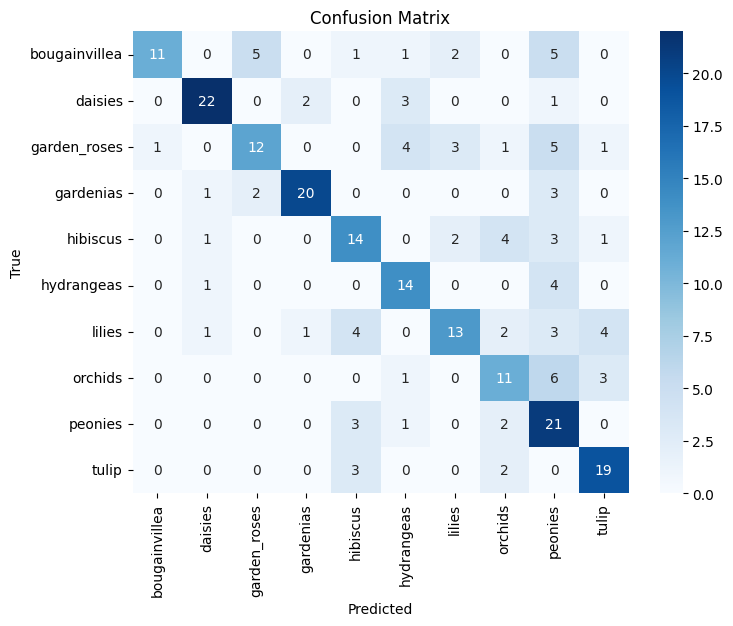

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_acc * 100:.2f}% | Test Loss: {test_loss:.4f}")

y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average="macro", zero_division=0)
rec  = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1   = f1_score(y_true, y_pred, average="macro", zero_division=0)

print(f"Accuracy = {acc:.3f} | Precision = {prec:.3f} | Recall = {rec:.3f} | F1 = {f1:.3f}")

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


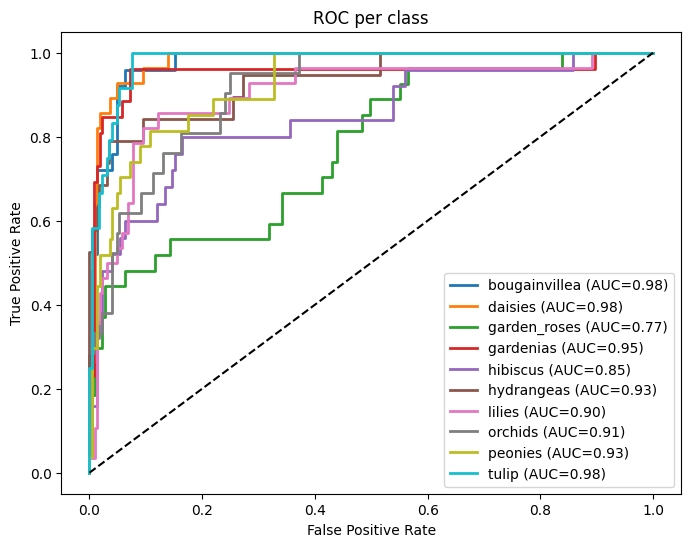

Average AUC (OvR): 0.918


In [ ]:

# Plot the ROC

plt.figure(figsize=(8,6))
roc_vals = []
for i in range(num_classes):
    if (y_test[:, i] > 0.5).any():
        fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
        roc_auc = auc(fpr, tpr)
        roc_vals.append(roc_auc)
        plt.plot(fpr, tpr, lw=2, label=f"{label_encoder.classes_[i]} (AUC={roc_auc:.2f})")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC per class")
plt.legend()
plt.show()

if roc_vals:
    print(f"Average AUC (OvR): {np.mean(roc_vals):.3f}")